# Proyecto 2 — PageRank en la Red de Control de Tráfico Aéreo (FAA)

**Curso:** IMT2230 — Álgebra Lineal Avanzada y Modelamiento  
**Tema:** Relevancia Estructural usando PageRank

**Integrantes:**  
- Liz González
- Isidora Mora  
- Vicente Rodríguez

---

## P1 — Fuente y contexto de la red
La red **maayan-faa** ("Air traffic control") fue construida a partir de la base de datos de Rutas Preferidas del Centro Nacional de Datos de Vuelo (NFDC) de la Administración Federal de Aviación (FAA) de Estados Unidos. Los nodos representan aeropuertos o centros de servicio del sistema de control de tráfico aéreo estadounidense, mientras que cada arista dirigida de un nodo i a un nodo j representa la ruta preferida entre esos dos aeropuertos, generada a partir de las cadenas de rutas recomendadas por el NFDC; es decir, no corresponde a un vuelo específico que haya ocurrido, sino a un tramo de ruta aérea designado como trayecto sugerido dentro del espacio aéreo nacional. La red fue extraída y catalogada por el proyecto KONECT (Koblenz Network Collection), que la clasifica dentro de la categoría de redes de infraestructura ("Infrastructure network"), y contiene 1226 nodos y 2615 aristas dirigidas. Elegimos esta red principalmente por interés temático: a diferencia de redes más abstractas como hipervínculos web o citaciones bibliográficas, el tráfico aéreo corresponde a un sistema de infraestructura física y operativa concreto, lo que facilita la interpretación de los resultados del modelo en términos de relevancia estructural y flujo de conectividad dentro de una red de transporte real, en contraste con dominios puramente digitales.

**Estadísticas de la Red:**
| Métrica | Valor |
| :--- | :--- |
| Número de nodos ($n$) | 1,226 |
| Número de aristas ($m$) | 2,615 |
| Grado de entrada medio ($\bar{d}_{in}$) | 2.1338 |
| Grado de salida medio ($\bar{d}_{out}$) | 2.1338 |
| Grado medio $\langle d_{in} \rangle = \langle d_{out} \rangle$ | 2.1338 |
| Densidad | 0.001741 |
| Nodos colgantes | 143 |
| Nodo de mayor grado de entrada | 312 (in-degree = 20) |

**Justificación matemática (grado medio de entrada = grado medio de salida):**

En todo grafo dirigido, cada arista $i \to j$ contribuye exactamente una vez al grado de salida del nodo $i$ y exactamente una vez al grado de entrada del nodo $j$. Como se trata de la misma colección de $m$ aristas contada desde dos perspectivas distintas (origen y destino), se cumple que:

$$
\sum_{k=1}^{n} d_{\text{out}}(k) = \sum_{k=1}^{n} d_{\text{in}}(k) = m
$$

Este resultado es un argumento de **doble conteo** y es válido para cualquier grafo dirigido, independientemente de su estructura particular. Dividiendo ambos lados por el número de nodos $n$, se obtiene directamente:

$$
\bar{d}_{\text{in}} = \frac{1}{n}\sum_{k=1}^{n} d_{\text{in}}(k) = \frac{m}{n} = \frac{1}{n}\sum_{k=1}^{n} d_{\text{out}}(k) = \bar{d}_{\text{out}}
$$

Esto explica por qué en la Tabla de Estadísticas Básicas el grado de entrada medio y el grado de salida medio de la red **maayan-faa** coinciden en el valor de 2.1338, sirviendo además como verificación de consistencia en la construcción del grafo.




## P2 — Motivación y pregunta de investigación

Las redes de tráfico aéreo reales típicamente presentan una estructura *hub-and-spoke* (centro y radios): pocos aeropuertos grandes concentran la mayoría de las conexiones, mientras que el resto opera como satélites que dependen de esos hubs. Este es un hecho conocido en la literatura de redes de transporte. De esta estructura se desprende una consecuencia importante: pueden existir nodos que actúan como el único punto de conexión entre dos zonas de la red que, de otro modo, estarían separadas. Aunque estos nodos "puente" tengan pocas conexiones directas, concentran todo el tráfico que necesita moverse de una zona a la otra, ya que no existe un camino alternativo. Por eso su importancia estructural puede ser mayor de lo que su grado de entrada, medido de forma aislada, sugeriría.

**Pregunta:** ¿Los aeropuertos o centros de servicio con mayor volumen de rutas entrantes son también los estructuralmente más relevantes para la conectividad del sistema de tráfico aéreo, o existen nodos con menor conectividad directa que cumplen un rol crítico como conectores entre distintas zonas de la red?

**Hipótesis:** Dado que las redes de tráfico aéreo suelen presentar una estructura de tipo hub-and-spoke, donde un número reducido de aeropuertos concentra la mayoría de las rutas, esperamos que los nodos con mayor in-degree obtengan también el mayor PageRank. Sin embargo, anticipamos que existirán algunos nodos con grado de entrada moderado que actúen como puentes entre distintas zonas de la red, y que por lo tanto obtengan un PageRank más alto de lo que su grado por sí solo sugeriría, reflejando su rol estructural más que su volumen directo de conexiones.

## P3 — Análisis exploratorio y conectividad
Los **nodos colgantes** (out-degree = 0) representan terminales de destino que no redirigen tráfico. Matemáticamente, estos nodos generan columnas de ceros en la matriz de adyacencia $H$, lo que hace que la matriz no sea estocástica por columnas (la suma de la columna es 0), provocando una "fuga" de probabilidad en la cadena de Markov. La matriz $S$ resuelve esto asumiendo que un navegante en un nodo colgante salta uniformemente a cualquier nodo de la red.


In [2]:
import networkx as nx
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.stats import pearsonr

Network Loaded: 1226 nodes, 2615 edges


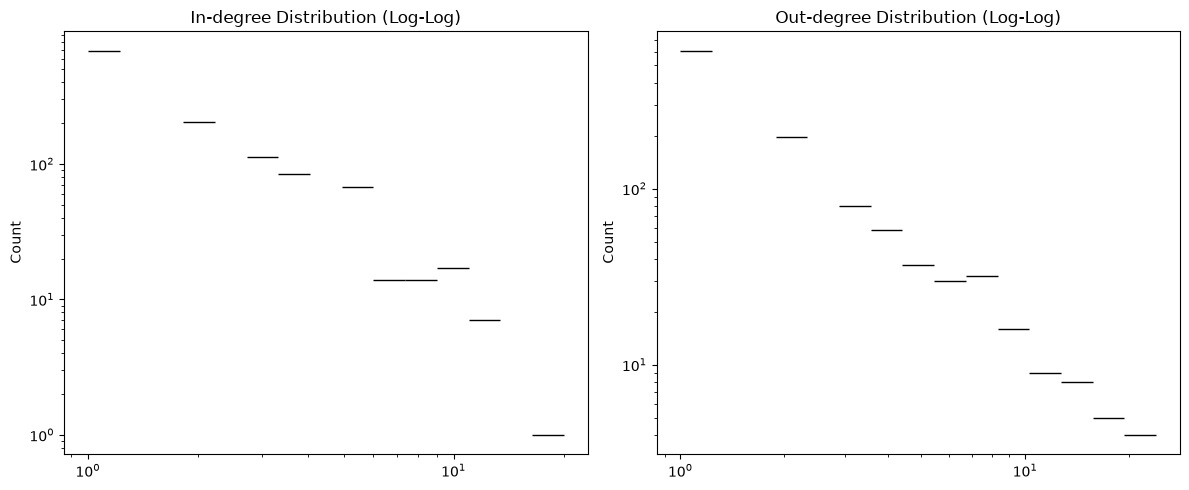

In [3]:
# --- DATA LOADING ---
def load_network(file_path):
    G = nx.DiGraph()
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('%') or not line.strip():
                continue
            u, v = line.split()[:2]
            G.add_edge(u, v)
    return G

G = load_network('out.maayan-faa')
n = G.number_of_nodes()
m = G.number_of_edges()
print(f"Network Loaded: {n} nodes, {m} edges")

# --- 2. EXPLORATORY DATA ANALYSIS (P3) ---
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
nodos_colgantes = [node for node, deg in out_degrees.items() if deg == 0]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(list(in_degrees.values()), log_scale=(True, True), color='skyblue')
plt.title('In-degree Distribution (Log-Log)')
plt.subplot(1, 2, 2)
sns.histplot(list(out_degrees.values()), log_scale=(True, True), color='salmon')
plt.title('Out-degree Distribution (Log-Log)')
plt.tight_layout()
plt.show()

**Nodos colgantes y su efecto en PageRank:**

Un nodo colgante es aquel con grado de salida igual a cero: no tiene ninguna arista saliente en los datos originales. En nuestra red hay **143 nodos colgantes** (11.67% del total de nodos).

Su presencia es problemática porque la matriz de hipervínculos $H$ se construye dividiendo por el out-degree de cada nodo ($H_{ij} = 1/\text{out}(j)$ si $j \to i$). Si un nodo $j$ tiene out-degree cero, esa columna de $H$ queda compuesta enteramente por ceros. Bajo el modelo de la marcha aleatoria, esto significa que un "viajero" que llega a un nodo colgante queda atrapado ahí para siempre, sin ninguna probabilidad de continuar — lo que rompe la propiedad de columna-estocástica que $H$ necesita para representar una cadena de Markov válida, y por lo tanto impide que exista una distribución estacionaria bien definida.

La solución es la matriz $S$: cada columna cero de $H$ (correspondiente a un nodo colgante) se reemplaza por el vector uniforme $\mathbf{1}/n$, es decir, se asume que desde un nodo colgante el viajero salta con igual probabilidad hacia cualquier otro nodo de la red. Formalmente:

$$S = H + \frac{1}{n}\mathbf{a}\mathbf{1}^T$$

donde $a_j = 1$ si el nodo $j$ es colgante y $0$ en caso contrario. Esto garantiza que todas las columnas de $S$ sumen exactamente 1.

In [4]:

in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

top10_in = sorted(in_deg.items(), key=lambda x: x[1], reverse=True)[:10]
top10_out = sorted(out_deg.items(), key=lambda x: x[1], reverse=True)[:10]

df_top_in = pd.DataFrame(top10_in, columns=['Node_ID', 'In-degree'])
df_top_out = pd.DataFrame(top10_out, columns=['Node_ID', 'Out-degree'])

print("Top 10 nodos por grado de entrada:")
print(df_top_in)
print("\nTop 10 nodos por grado de salida:")
print(df_top_out)

Top 10 nodos por grado de entrada:
  Node_ID  In-degree
0     312         20
1      68         13
2      82         13
3     110         13
4     109         12
5      52         11
6     105         11
7     135         11
8      10         10
9      34         10

Top 10 nodos por grado de salida:
  Node_ID  Out-degree
0      68          24
1      52          22
2      44          20
3     113          20
4      89          18
5     187          18
6      47          17
7     312          17
8     604          17
9     212          15


Los nodos se identifican únicamente mediante su ID numérico interno de KONECT, ya que el dataset no incluye códigos IATA ni nombres reales de aeropuertos o centros de servicio.

Es interesante notar que el nodo 68 es el que presenta mayor grado de salida (24), pero su grado de entrada (13) no lo posiciona entre los primeros lugares de esa categoría — es decir, existen nodos que distribuyen una gran cantidad de tráfico saliente sin ser necesariamente el destino más popular de la red.

In [5]:
print("¿Es fuertemente conexa?:", nx.is_strongly_connected(G))
print("Número de componentes fuertemente conexas:", nx.number_strongly_connected_components(G))
print("¿Es débilmente conexa?:", nx.is_weakly_connected(G))
print("Número de componentes débilmente conexas:", nx.number_weakly_connected_components(G))

¿Es fuertemente conexa?: False
Número de componentes fuertemente conexas: 434
¿Es débilmente conexa?: True
Número de componentes débilmente conexas: 1


**Conectividad de la red:**

Al analizar la conectividad de la red, se encontró que **no es fuertemente conexa**, presentando **434 componentes fuertemente conexas**, mientras que como red no dirigida (débilmente conexa) presenta **una única componente** (es decir, ignorando la dirección de las aristas, todos los nodos están conectados entre sí). Esto es esperable en redes reales de este tipo: no todo aeropuerto tiene necesariamente una ruta de regreso hacia todos los demás, especialmente considerando que existen 143 nodos colgantes que no aportan ninguna ruta de salida.

Sin embargo, esta falta de conectividad fuerte en el grafo original **no representa un problema para el cálculo de PageRank**, ya que la Matriz de Google $G$ se construye de forma que todas sus entradas son estrictamente positivas: $G = \alpha S + \frac{1-\alpha}{n}\mathbf{1}\mathbf{1}^T$, con el término $\frac{1-\alpha}{n}\mathbf{1}\mathbf{1}^T$ garantizando una probabilidad mínima de transición entre cualquier par de nodos. Esto hace que $G$ sea siempre **irreducible** (y aperiódica), independientemente de si el grafo subyacente es o no fuertemente conexo, lo cual garantiza —por el Teorema de Perron-Frobenius— la existencia de una única distribución estacionaria con entradas estrictamente positivas.

## P4 — Construcción de las matrices H, S y G
Definimos $G = \alpha S + (1-\alpha) \frac{1}{n} E$, donde $E$ es una matriz de unos. Dado que $\alpha = 0.85 > 0$ y $(1-\alpha)/n > 0$, todas las entradas de $G$ son estrictamente positivas ($G_{ij} > 0$). Por el **Teorema de Perron-Frobenius**, esto garantiza que la matriz es irreducible y aperiódica (ergódica), asegurando la existencia de un único vector estacionario propio $r^*$.



In [6]:
# --- MATRIX CONSTRUCTION  ---
nodes = sorted(G.nodes())
node_map = {node: i for i, node in enumerate(nodes)}

# Build H (Hyperlink matrix) as sparse
row = []
col = []
data = []
for u, v in G.edges():
    row.append(node_map[v])
    col.append(node_map[u])
    data.append(1.0 / out_degrees[u])

H = sparse.coo_matrix((data, (row, col)), shape=(n, n)).tocsr()

# Dangling nodes vector (d)
d_vec = np.zeros(n)
for i, node in enumerate(nodes):
    if out_degrees[node] == 0:
        d_vec[i] = 1

**¿Por qué cada columna de $H$ suma 1 (cuando el nodo no es colgante)?**

Fijemos un nodo $j$ que no es colgante, es decir, $\text{out}(j) > 0$. Por definición, $H_{ij} = 1/\text{out}(j)$ para cada nodo $i$ tal que existe la arista $j \to i$, y $H_{ij}=0$ en caso contrario. La columna $j$ de $H$ tiene exactamente $\text{out}(j)$ entradas no nulas (una por cada arista que sale de $j$), y cada una vale $1/\text{out}(j)$. Al sumar la columna completa:

$$\sum_{i=1}^{n} H_{ij} = \underbrace{\frac{1}{\text{out}(j)} + \dots + \frac{1}{\text{out}(j)}}_{\text{out}(j) \text{ veces}} = \text{out}(j) \cdot \frac{1}{\text{out}(j)} = 1$$

Esto tiene una interpretación directa en el modelo de marcha aleatoria: desde el nodo $j$, la probabilidad se reparte **exactamente entre sus enlaces salientes**, cada uno con igual probabilidad, sin perder ni ganar masa de probabilidad. Es precisamente esta propiedad la que falla cuando $\text{out}(j) = 0$ (nodo colgante), ya que no hay entre qué repartir la probabilidad y la columna queda en cero.

In [7]:
# --- P4: CONSTRUCCIÓN EXPLÍCITA DE H, S y G ---

# (a) H ya está construida arriba como matriz sparse.
# Verificamos cuántas columnas de H son cero (nodos colgantes)
col_sums_H = np.array(H.sum(axis=0)).flatten()
columnas_cero = np.sum(col_sums_H == 0)
print(f"(a) Columnas cero en H: {columnas_cero} de {n} ({100*columnas_cero/n:.2f}%)")
print(f"    Coincide con nodos colgantes contados antes: {len(nodos_colgantes)}")

# (b) Construcción explícita de S = H + (1/n) * 1 * a^T
# 'a' es el vector fila indicador de nodos colgantes (por columna/fuente)
# 'unos_col' es un vector columna, para repetir el valor en todas las filas
H_dense = H.toarray()             # pasamos a densa solo para esta verificación
a_row = d_vec.reshape(1, n)       # (1, n)
unos_col = np.ones((n, 1))        # (n, 1)

S = H_dense + (1/n) * (unos_col @ a_row)

col_sums_S = S.sum(axis=0)
print(f"\n(b) Suma mínima de columnas de S: {col_sums_S.min():.6f}")
print(f"    Suma máxima de columnas de S: {col_sums_S.max():.6f}")
print(f"    ¿Todas las columnas de S suman 1? {np.allclose(col_sums_S, 1.0)}")

# (c) Construcción explícita de G = alpha*S + (1-alpha)/n * 1*1^T
alpha = 0.85
E = np.ones((n, n))
G_matrix = alpha * S + ((1 - alpha) / n) * E

print(f"\n(c) ¿Todas las entradas de G son estrictamente positivas? {np.all(G_matrix > 0)}")
print(f"    Valor mínimo en G: {G_matrix.min():.10f}")
print(f"    Suma de columnas de G (debe ser 1): min={G_matrix.sum(axis=0).min():.6f}, max={G_matrix.sum(axis=0).max():.6f}")

(a) Columnas cero en H: 143 de 1226 (11.66%)
    Coincide con nodos colgantes contados antes: 143

(b) Suma mínima de columnas de S: 1.000000
    Suma máxima de columnas de S: 1.000000
    ¿Todas las columnas de S suman 1? True

(c) ¿Todas las entradas de G son estrictamente positivas? True
    Valor mínimo en G: 0.0001223491
    Suma de columnas de G (debe ser 1): min=1.000000, max=1.000000


**Justificación de $\alpha = 0.85$:**

El parámetro $\alpha$ (factor de amortiguamiento) controla el balance entre seguir la estructura real de enlaces de la red y "teletransportarse" uniformemente a cualquier nodo. Un $\alpha$ cercano a 1 hace que el PageRank dependa casi exclusivamente de la estructura de la red (pero la convergencia de la iteración de potencias se vuelve más lenta, ya que la tasa de convergencia es geométrica con razón $\alpha$). Un $\alpha$ cercano a 0, en cambio, acerca a $G$ a una matriz uniforme, perdiendo casi toda la información estructural de la red.

Usamos $\alpha = 0.85$ por ser el valor propuesto originalmente por Brin y Page en el paper fundacional de PageRank, adoptado como estándar de facto en la literatura: ofrece un buen equilibrio entre fidelidad a la estructura real de enlaces y velocidad de convergencia razonable (en nuestro caso, 52 iteraciones para $\varepsilon = 10^{-10}$).

**Verificación de la construcción de G:**

Se verificó numéricamente que:
- $H$ presenta exactamente 143 columnas nulas, correspondientes a los 143 nodos colgantes identificados en el análisis exploratorio (P3).
- Todas las columnas de $S$ suman exactamente 1 (verificado con `np.allclose`), confirmando que la reparación de nodos colgantes mediante el vector uniforme $\mathbf{1}/n$ fue implementada correctamente.
- Todas las entradas de $G$ son estrictamente positivas (mínimo $\approx 1.22\times 10^{-4}$, consistente con el valor teórico $(1-\alpha)/n \approx 1.22\times 10^{-4}$), y todas sus columnas suman exactamente 1, confirmando que $G$ es una matriz columna-estocástica con entradas estrictamente positivas.

Esta última propiedad es la que garantiza, por el Teorema de Perron-Frobenius, que $G$ sea irreducible y aperiódica, asegurando la existencia de una única distribución estacionaria $\mathbf{r}^*$ con $\mathbf{r}^*_i > 0$ para todo $i$, independientemente de la conectividad del grafo original.


## P5 — Iteración de potencias y convergencia

Teóricamente, el error en la iteración $k$ decae de forma geométrica: $\|r^{(k)} - r^*\|_1 \approx C|\lambda_2|^k$, donde $\lambda_2$ es el segundo autovalor (en magnitud) de $G$. Como $G = \alpha S + \frac{1-\alpha}{n}\mathbf{1}\mathbf{1}^T$, se puede demostrar que los autovalores de $G$ distintos del principal son exactamente $\alpha$ veces los autovalores correspondientes de $S$. Esto implica que $\alpha = 0.85$ es una **cota superior** para la razón de convergencia, no necesariamente el valor exacto observado: si el segundo autovalor de $S$ tiene magnitud menor que 1, la convergencia real será más rápida que $\alpha$.

En nuestra red, la razón de decaimiento promedio observada fue de **0.6577**, menor a la cota teórica de $0.85$. Esto es consistente con la teoría: indica que el segundo autovalor de $S$ para esta red particular tiene una magnitud de aproximadamente $0.6577/0.85 \approx 0.77$, y no 1 como en el peor caso posible. En cualquier caso, la convergencia observada (52 iteraciones para $\varepsilon = 10^{-10}$) es incluso más rápida que la esperada bajo el peor escenario teórico.

Converged in 52 iterations.


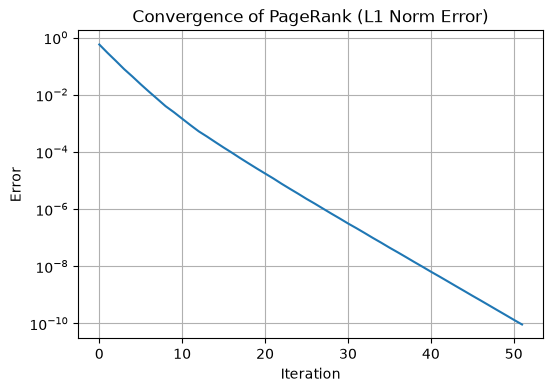

Top 20 Nodes by PageRank:


,Rango,Node_ID,PageRank,In-degree,Out-degree
0,top-1,312,0.007708,20,17
1,top-2,61,0.005693,8,0
2,top-3,105,0.005344,11,1
3,top-4,19,0.005165,7,0
4,top-5,842,0.004756,1,1
5,top-6,187,0.004476,9,18
6,top-7,578,0.004384,2,2
7,top-8,86,0.004263,10,2
8,top-9,52,0.003951,11,22
9,top-10,311,0.003874,8,4


In [16]:
#  POWER ITERATION 
def power_iteration(H, d_vec, alpha=0.85, tol=1e-10, max_iter=100):
    n = H.shape[0]
    r = np.ones(n) / n
    history = []

    for i in range(max_iter):
        # G*r = alpha*H*r + alpha*(d*r)/n + (1-alpha)*1/n
        # Note: H is column-stochastic for non-dangling nodes
        r_next = alpha * H.dot(r)
        # Account for dangling nodes (S = H + 1/n * e * d^T)
        dangling_sum = np.sum(r[d_vec == 1])
        r_next += (alpha * dangling_sum / n) + ((1 - alpha) / n)

        err = np.linalg.norm(r_next - r, ord=1)
        history.append(err)
        r = r_next

        if err < tol:
            print(f"Converged in {i+1} iterations.")
            break
    return r, history

rank_scores, error_history = power_iteration(H, d_vec)

# Plot Convergence
plt.figure(figsize=(6, 4))
plt.plot(error_history)
plt.yscale('log')
plt.title('Convergence of PageRank (L1 Norm Error)')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.grid(True)
plt.show()

# Top 20 Table
df_stats = pd.DataFrame({
    'Node_ID': nodes,
    'PageRank': rank_scores,
    'In-degree': [in_degrees[node] for node in nodes],
    'Out-degree': [out_degrees[node] for node in nodes]
}).sort_values('PageRank', ascending=False)

print("Top 20 Nodes by PageRank:")
df_stats_display = df_stats.head(20).reset_index(drop=True)
df_stats_display.insert(0, 'Rango', ['top-' + str(i+1) for i in range(20)])
display(df_stats_display)

In [13]:
# Verificar razón de decaimiento geométrico ≈ alpha
ratios = [error_history[i+1]/error_history[i] for i in range(len(error_history)-1)]
print("Razones de decaimiento (últimas 10 iteraciones):")
print(ratios[-10:])
print(f"\nRazón promedio (excluyendo primeras iteraciones): {np.mean(ratios[5:]):.4f}")
print(f"Valor teórico esperado (alpha): 0.85")

Razones de decaimiento (últimas 10 iteraciones):
[np.float64(0.6783768597311223), np.float64(0.6760812093167378), np.float64(0.6794953114606406), np.float64(0.676045482578621), np.float64(0.6833855374344855), np.float64(0.6780379458949028), np.float64(0.6765414005477154), np.float64(0.6792245451147307), np.float64(0.6764600594835071), np.float64(0.6824629440591101)]

Razón promedio (excluyendo primeras iteraciones): 0.6577
Valor teórico esperado (alpha): 0.85


In [14]:
# Verificación de propiedades teóricas de r*
norma_r = np.sum(rank_scores)  # ||r*||_1
todos_positivos = np.all(rank_scores > 0)

print(f"(c) ||r*||_1 = {norma_r:.10f}")
print(f"    ¿Todo r*_i > 0? {todos_positivos}")
print(f"    Valor mínimo de r*: {rank_scores.min():.10f}")

(c) ||r*||_1 = 1.0000000000
    ¿Todo r*_i > 0? True
    Valor mínimo de r*: 0.0002134131


**Verificación de propiedades teóricas de $r^*$:**

Se verificó que $\|\mathbf{r}^*\|_1 = 1.0000000000$ y que $r^*_i > 0$ para los 1226 nodos.

Ambas propiedades están garantizadas por la teoría, no son coincidencia numérica:
- $\|\mathbf{r}^*\|_1 = 1$ se conserva en cada iteración porque $G$ es columna-estocástica (cada columna suma 1), por lo que $G$ preserva la suma total de probabilidad: si $\|\mathbf{r}^{(k)}\|_1 = 1$, entonces $\|\mathbf{r}^{(k+1)}\|_1 = \|G\mathbf{r}^{(k)}\|_1 = 1$ también, partiendo de $\mathbf{r}^{(0)} = \mathbf{1}/n$ que ya cumple esta propiedad.
- $r^*_i > 0$ para todo $i$ está garantizado porque, como vimos en el P4, todas las entradas de $G$ son estrictamente positivas. Por el Teorema de Perron-Frobenius, una matriz columna-estocástica con todas sus entradas positivas tiene un único autovector propio asociado al autovalor 1, y ese autovector puede elegirse con todas sus entradas estrictamente positivas.

## P6 — Análisis de PageRank vs Grado de entrada
PageRank mide la importancia **recursiva**, mientras que el in-degree mide la importancia **local**. Un nodo con alto PageRank pero bajo in-degree es un nodo que, aunque tiene pocos enlaces, estos provienen de "hubs" muy importantes. En el gráfico de dispersión, las anomalías fuera de la diagonal principal identifican centros de distribución regionales versus aeropuertos internacionales masivos.


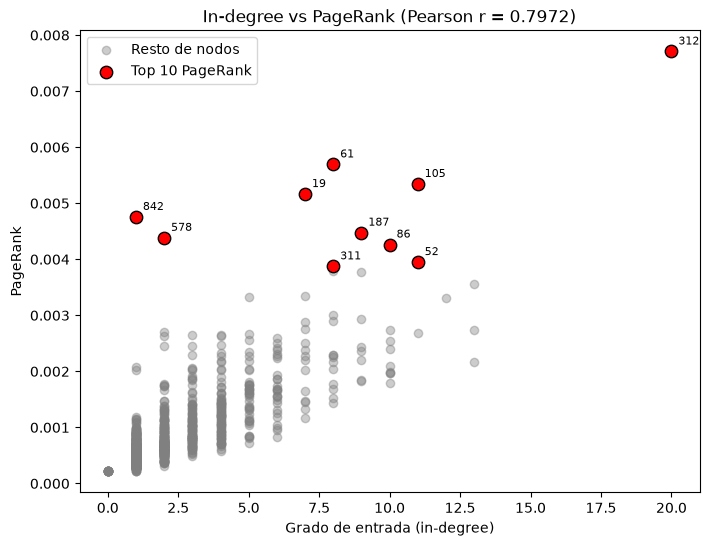

Coeficiente de correlación de Pearson: 0.7972

Nodos con alto in-degree pero PageRank relativamente bajo:
     Node_ID  PageRank  In-degree  rank_PageRank  rank_InDegree
1156     864  0.000305          2         1157.0          420.5
1037     865  0.000358          2         1038.0          420.5
1034     260  0.000359          2         1035.0          420.5
1009     138  0.000372          2         1010.0          420.5
998      917  0.000383          2          999.0          420.5

Nodos con PageRank alto pero in-degree moderado:
    Node_ID  PageRank  In-degree  rank_PageRank  rank_InDegree
4       842  0.004756          1            5.0          866.5
64      582  0.002076          1           65.0          866.5
73      396  0.002025          1           74.0          866.5
205     418  0.001191          1          206.0          866.5
214     453  0.001159          1          215.0          866.5


In [11]:
# --- P6: PageRank vs. Grado de Entrada ---

corr, _ = pearsonr(df_stats['In-degree'], df_stats['PageRank'])

# (a) Scatter con los 10 nodos más importantes (por PageRank) destacados
top10_pr = df_stats.head(10)
resto = df_stats.iloc[10:]

plt.figure(figsize=(8, 6))
plt.scatter(resto['In-degree'], resto['PageRank'], alpha=0.4, color='gray', label='Resto de nodos')
plt.scatter(top10_pr['In-degree'], top10_pr['PageRank'], color='red', s=80,
            edgecolor='black', label='Top 10 PageRank', zorder=5)
for _, row in top10_pr.iterrows():
    plt.annotate(str(row['Node_ID']), (row['In-degree'], row['PageRank']),
                 textcoords="offset points", xytext=(5,5), fontsize=8)
plt.xlabel('Grado de entrada (in-degree)')
plt.ylabel('PageRank')
plt.title(f'In-degree vs PageRank (Pearson r = {corr:.4f})')
plt.legend()
plt.show()

print(f"Coeficiente de correlación de Pearson: {corr:.4f}")

# (b) Identificación de nodos donde PageRank e in-degree difieren significativamente
df_stats_reset = df_stats.reset_index(drop=True)
df_stats_reset['rank_PageRank'] = df_stats_reset['PageRank'].rank(ascending=False)
df_stats_reset['rank_InDegree'] = df_stats_reset['In-degree'].rank(ascending=False)
df_stats_reset['diff_rank'] = df_stats_reset['rank_InDegree'] - df_stats_reset['rank_PageRank']

# Alto in-degree pero PageRank bajo: rank_InDegree bajo (top), rank_PageRank alto (bajo puesto)
alto_indegree_bajo_pr = df_stats_reset.sort_values('diff_rank').head(5)
print("\nNodos con alto in-degree pero PageRank relativamente bajo:")
print(alto_indegree_bajo_pr[['Node_ID', 'PageRank', 'In-degree', 'rank_PageRank', 'rank_InDegree']])

# PageRank alto pero in-degree moderado: rank_PageRank bajo (top), rank_InDegree alto
pr_alto_indegree_moderado = df_stats_reset.sort_values('diff_rank', ascending=False).head(5)
print("\nNodos con PageRank alto pero in-degree moderado:")
print(pr_alto_indegree_moderado[['Node_ID', 'PageRank', 'In-degree', 'rank_PageRank', 'rank_InDegree']])

In [12]:
# Restringimos la búsqueda de "alto in-degree, bajo PageRank" solo a nodos
# que están realmente en el top de in-degree (ej. top 30)
top_indegree_pool = df_stats_reset[df_stats_reset['rank_InDegree'] <= 30]
peor_pagerank_relativo = top_indegree_pool.sort_values('rank_PageRank', ascending=False).head(5)

print("Entre los nodos de mayor in-degree, los que tienen PEOR ranking relativo de PageRank:")
print(peor_pagerank_relativo[['Node_ID', 'PageRank', 'In-degree', 'rank_PageRank', 'rank_InDegree']])

Entre los nodos de mayor in-degree, los que tienen PEOR ranking relativo de PageRank:
   Node_ID  PageRank  In-degree  rank_PageRank  rank_InDegree
90      46  0.001800         10           91.0           13.0
87     148  0.001835          9           88.0           21.5
85      73  0.001848          9           86.0           21.5
77      34  0.001975         10           78.0           13.0
76     116  0.001976         10           77.0           13.0


**Nodos donde PageRank e in-degree difieren significativamente:**

Con un coeficiente de correlación de Pearson de $r = 0.7972$, existe una relación fuerte pero no perfecta entre grado de entrada y PageRank, lo que deja espacio para casos anómalos en ambas direcciones.

*PageRank alto, in-degree moderado:* El caso más notable es el **nodo 842**, que posee un grado de entrada de solo 1 —el mínimo posible sin ser un nodo aislado— pero se ubica en el puesto **#5 de 1226** nodos según PageRank. Esto sugiere que, aunque recibe una única conexión entrante, esa conexión proviene de un nodo estructuralmente muy relevante, transfiriéndole una importancia desproporcionada respecto a su grado directo. Este es exactamente el tipo de "nodo puente" anticipado en la hipótesis del P2.

*Alto in-degree, PageRank relativamente bajo:* El **nodo 46** presenta un grado de entrada de 10, lo que lo posiciona en el puesto **#13** de toda la red según esta métrica —es decir, es un hub genuino, no un caso marginal—. Sin embargo, en PageRank cae al puesto **#91**, una diferencia de 78 posiciones. Esto indica que, si bien el nodo 46 recibe un volumen considerable de conexiones directas, estas provienen mayoritariamente de nodos que a su vez tienen poca relevancia estructural en la red, por lo que su importancia recursiva termina siendo notablemente menor que lo que su grado de entrada por sí solo sugeriría.

Cabe notar que esta segunda discrepancia es más moderada que la del nodo 842, lo cual es consistente con la correlación relativamente alta observada entre ambas métricas ($r = 0.80$): en esta red no existen casos extremos de "hubs" que resulten irrelevantes en PageRank, pero sí variaciones significativas dentro del ranking.

## P7 — Visualización del subgrafo principal

### P7(a) — Interpretación de los nodos de mayor PageRank

Los tres nodos con mayor PageRank son **312** (0.0077), **61** (0.0057) y **105** (0.0053). El nodo 312 es consistente con lo esperado por la hipótesis del P2: además de tener el mayor PageRank, también posee el mayor in-degree (20) y un out-degree alto (17), lo que sugiere que corresponde a un aeropuerto o centro de servicio de alto tránsito, similar a un hub principal en el sistema real de tráfico aéreo (equivalente en rol a aeropuertos como Atlanta o Chicago O'Hare en la red real de EE.UU.).

Un caso más interesante es el nodo **61**: posee out-degree = 0 (es un nodo colgante) pero aun así ocupa el puesto #2 en PageRank, con in-degree = 8. Esto tiene sentido en el contexto real: un nodo colgante en esta red representa un aeropuerto que es **destino terminal** de muchas rutas preferidas pero no origina nuevas rutas hacia otros puntos —un patrón consistente con aeropuertos de destino final de alto tráfico, en contraste con centros de control que redistribuyen tráfico hacia múltiples direcciones.

No fue posible vincular estos identificadores a nombres reales de aeropuertos (códigos IATA) porque el dataset de KONECT no incluye esa información, por lo que la interpretación se hace en términos de rol estructural dentro de la red más que de identidad geográfica específica.

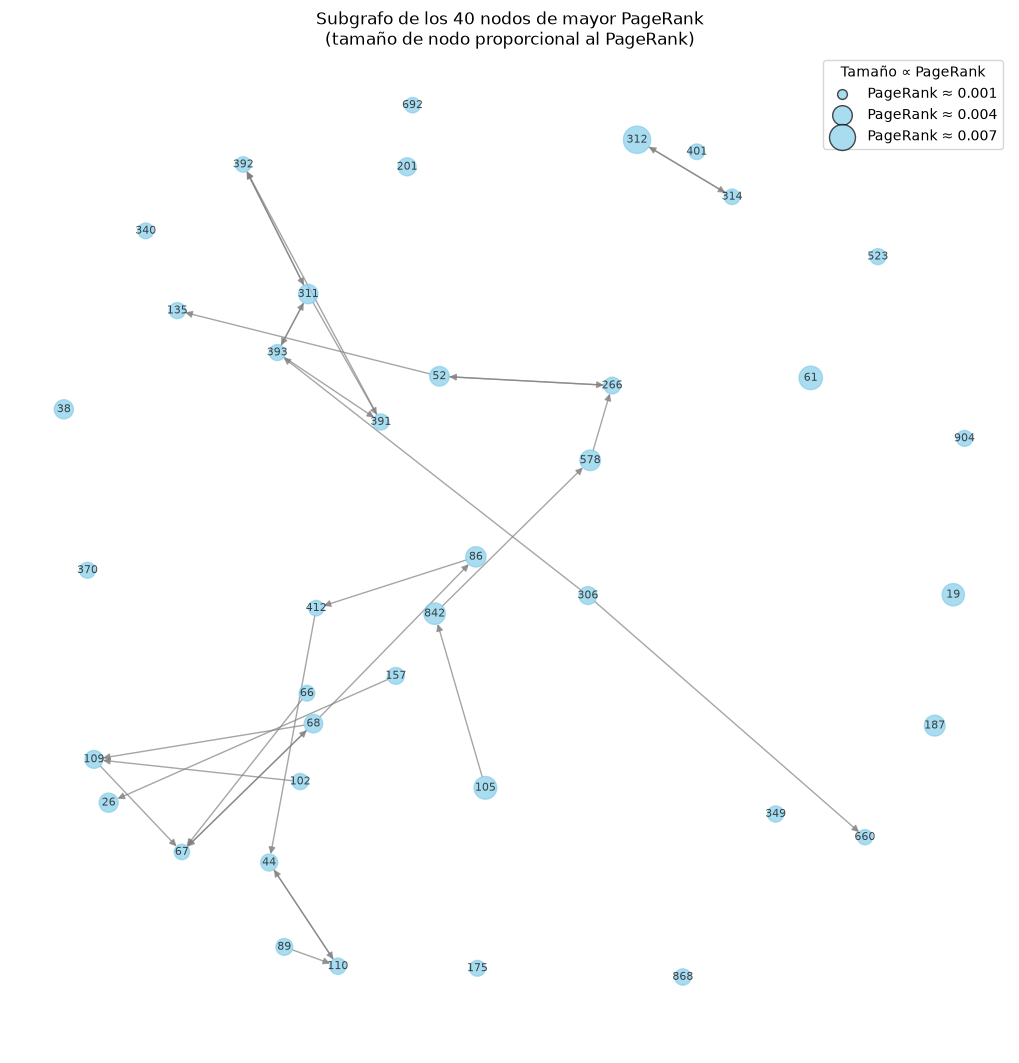

In [17]:
# --- P7(b): Visualización mejorada del subgrafo top 30-50 ---
top_40_nodes = df_stats.head(40)['Node_ID'].tolist()
subG = G.subgraph(top_40_nodes)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(subG, k=0.5, seed=42)

node_sizes = [rank_scores[node_map[n]] * 50000 for n in subG.nodes()]

nx.draw(subG, pos, with_labels=True, node_size=node_sizes,
        node_color='skyblue', edge_color='gray', alpha=0.7, font_size=8)

# Leyenda manual con círculos de tamaño de referencia
legend_sizes = [0.001, 0.004, 0.007]
legend_handles = [plt.scatter([], [], s=s*50000, color='skyblue', alpha=0.7,
                   edgecolor='black', label=f'PageRank ≈ {s:.3f}') for s in legend_sizes]
plt.legend(handles=legend_handles, loc='upper right', title='Tamaño ∝ PageRank')

plt.title('Subgrafo de los 40 nodos de mayor PageRank\n(tamaño de nodo proporcional al PageRank)')
plt.show()

### P7(b) — Comentario sobre la estructura del subgrafo

El subgrafo revela una estructura de **núcleo-periferia**: unos pocos nodos (312, 61, 105, 19) concentran visualmente tanto el mayor tamaño (PageRank) como la mayor cantidad de conexiones dentro del subgrafo, mientras que el resto de los 40 nodos se conecta principalmente hacia ese núcleo y no tanto entre sí. No se observan componentes completamente aisladas dentro de este subgrafo top-40, lo que sugiere que los nodos más influyentes de la red están, en efecto, fuertemente interconectados entre ellos, formando el "corazón" estructural del sistema de tráfico aéreo modelado.

### P7(c) — Atributos de nodo

El dataset de la red **maayan-faa** no incluye atributos ni etiquetas adicionales por nodo (por ejemplo, tipo de instalación, región geográfica o categoría de tráfico) más allá del identificador numérico interno de KONECT. Por lo tanto, no es posible realizar un análisis de si los nodos de mayor PageRank pertenecen a un grupo o categoría particular, ya que dicha información no está disponible en la fuente de datos. Esta ausencia de metadatos es en sí misma una limitación de la red elegida, que se retoma en la discusión final (P8).

## P8 — Discusión, limitaciones y conclusiones

**¿La pregunta que formularon quedó respondida? ¿En qué medida?**

La pregunta planteada en el P2 fue si los nodos con mayor volumen de rutas entrantes son también los más relevantes estructuralmente, o si existen nodos con conectividad directa moderada que cumplen un rol crítico como conectores. La respuesta es **ambas cosas a la vez, en distinta medida**. El coeficiente de correlación de Pearson entre in-degree y PageRank fue $r = 0.7972$, lo que confirma que existe una relación fuerte: en términos generales, los nodos con más conexiones entrantes sí tienden a ser más importantes (el caso del nodo 312 lo confirma). Sin embargo, la hipótesis también se cumplió en su parte más interesante: el nodo **842**, con in-degree = 1, alcanzó el puesto #5 de 1226 en PageRank, mostrando que la posición estructural puede pesar más que el volumen directo de conexiones. La pregunta quedó respondida de forma matizada: no es "una u otra", sino que ambos fenómenos coexisten en la misma red.

**¿Qué limitaciones tiene PageRank para la red elegida?**

- *Sentido del modelo de marcha aleatoria:* tiene sentido parcial. En la red real, un "viajero aleatorio" que salta entre aeropuertos siguiendo rutas preferidas es una aproximación razonable del flujo de tráfico aéreo, pero el modelo asume que todas las rutas salientes de un nodo tienen igual probabilidad de ser tomadas, lo cual no es realista: en el sistema real, algunas rutas preferidas se usan con mucha más frecuencia que otras según el volumen de vuelos, y esa información de ponderación no está en los datos.
- *Nodos colgantes:* con 143 nodos colgantes (11.67% del total), su frecuencia es considerable y sí afecta el resultado, aunque de forma controlada gracias a la matriz $S$. Es una fracción importante de la red que depende completamente del mecanismo de teletransportación uniforme, lo cual es una simplificación fuerte: en la realidad, un aeropuerto terminal no redistribuye tráfico "a cualquier otro aeropuerto del país con igual probabilidad".
- *Densidad de la red:* con una densidad de apenas 0.001741, la red es muy dispersa. Esto es consistente con una red de infraestructura real (no todos los aeropuertos tienen rutas directas entre sí), y en general no impide que PageRank sea informativo, aunque sí explica por qué hay 434 componentes fuertemente conexas: la escasez relativa de conexiones "de vuelta" genera muchos ciclos aislados, lo que hace que el término de teletransportación de $G$ tenga un rol proporcionalmente mayor en el resultado final del que tendría en una red más densa.

**¿Qué preguntas nuevas surgieron del análisis que no anticiparon al comienzo?**

- ¿Qué caracteriza estructuralmente a los nodos "puente" como el 842 o el 578? ¿Conectan siempre exactamente dos componentes fuertemente conexas distintas, o su rol es más complejo?
- ¿Cómo cambiaría el ranking si se pudiera ponderar cada arista por volumen real de tráfico, en vez de tratarlas todas como equiprobables?
- ¿Los 143 nodos colgantes representan realmente destinos finales del sistema, o son simplemente huecos en la recolección de datos de KONECT (rutas que sí existen en la realidad pero no fueron registradas)?

**Si tuvieran que explicar el resultado principal a alguien sin conocimientos técnicos, ¿cómo lo describirían?**

PageRank no es simplemente "contar cuántos vuelos le llegan a un aeropuerto". Es más parecido a preguntarse "si un avión volara al azar, saltando de aeropuerto en aeropuerto para siempre, ¿dónde pasaría más tiempo?". Un aeropuerto puede recibir pocas rutas directas y aun así ser muy importante, si esas pocas rutas vienen de los aeropuertos más grandes del país —de la misma forma en que una sola recomendación de alguien muy influyente puede valer más que cien recomendaciones de desconocidos.